# 🏆 Datathon Contest — Analytics Dashboard
> A comprehensive analysis of our hackathon registration, participation, and submission data for partner reporting.

---
## 1. Setup & Data Loading

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import ast
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = ['#778be7', '#f4cccc', '#d9ead3', '#F72585', '#4CC9F0',
           '#4895EF', '#ffe599', '#9fc5e8', '#FF6B6B', '#48BFE3']
sns.set_palette(PALETTE)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

print("✅ Libraries loaded & styling applied.")

✅ Libraries loaded & styling applied.


In [52]:
# ── Load Data ────────────────────────────────────────────────
df = pd.read_csv('data3.csv') #Put the latest version of the dataset here
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: 159 rows × 11 columns
Columns: ['Team ID', 'Team Name', 'contactEmail', 'institution', 'members', 'registeredAt', 'round1EmailSent', 'round1Submission', 'round2EmailSent', 'round2Submission', 'status']


,Team ID,Team Name,contactEmail,institution,members,registeredAt,round1EmailSent,round1Submission,round2EmailSent,round2Submission,status
0,0xZ6Wl110SbbldBH4zXH,4 gacon,decomchay@gmail.com,Đại học Giao Thông Vận Tải Thành Phố Hồ Chí Mi...,"[{""role"":""team_leader"",""memberName"":""Hồ Thành ...","March 23, 2026 at 7:27:24 PM UTC+7",False,NaN,False,NaN,registered
1,20ZXmM80SMyT0noOzCsZ,a8-hbt,tunglamnguyenxd@gmail.com,Đại học Công nghệ Thông tin và Truyền thông Vi...,"[{""major"":""Khoa học Máy tính"",""university"":""Đạ...","March 24, 2026 at 11:56:59 PM UTC+7",False,NaN,False,NaN,registered
2,2T4ZvCdUxqRfCgkq20YE,Gugugaga,ngoctabao@gmail.com,FPT University,"[{""major"":""Trí tuệ nhân tạo"",""university"":""FPT...","March 24, 2026 at 11:54:56 AM UTC+7",False,NaN,False,NaN,registered
3,2iSlwOYq1PxB7qfbMg3W,duoq,thaitqse200526@fpt.edu.vn,Đại học FPT,"[{""role"":""team_leader"",""memberName"":""Trần Quan...","March 28, 2026 at 10:05:52 PM UTC+7",False,NaN,False,NaN,registered
4,2nqAYdRZjGd9uDZSwxGD,3P,tvu716714@gmail.com,Đại học Bách Khoa Hà Nội,"[{""major"":""Khoa học dữ liệu"",""university"":""Đại...","March 23, 2026 at 11:21:11 PM UTC+7",False,NaN,False,NaN,registered


---
## 2. Data Overview & Cleaning

In [53]:
# ── Quick info ───────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Team ID           159 non-null    object 
 1   Team Name         159 non-null    object 
 2   contactEmail      159 non-null    object 
 3   institution       159 non-null    object 
 4   members           159 non-null    object 
 5   registeredAt      159 non-null    object 
 6   round1EmailSent   159 non-null    bool   
 7   round1Submission  0 non-null      float64
 8   round2EmailSent   159 non-null    bool   
 9   round2Submission  0 non-null      float64
 10  status            159 non-null    object 
dtypes: bool(2), float64(2), object(7)
memory usage: 11.6+ KB


In [54]:
# ── Parse registeredAt to datetime ────────────────────────────
def parse_registration_date(date_str):
    """Parse the custom date format from the CSV."""
    if pd.isna(date_str):
        return pd.NaT
    try:
        # Try the format: "March 23, 2026 at 7:27:24 PM UTC+7"
        clean = date_str.replace('\xa0', ' ').strip()
        # Remove timezone info for parsing
        for tz in ['UTC+7', 'UTC+07', 'GMT+7', 'ICT']:
            clean = clean.replace(tz, '').strip()
        # Try multiple formats
        for fmt in [
            '%B %d, %Y at %I:%M:%S %p',
            '%B %d, %Y at %H:%M:%S',
            '%b %d, %Y at %I:%M:%S %p',
            '%Y-%m-%dT%H:%M:%S',
        ]:
            try:
                return pd.to_datetime(clean, format=fmt)
            except (ValueError, TypeError):
                continue
        return pd.to_datetime(clean)
    except Exception:
        return pd.NaT

df['registered_dt'] = df['registeredAt'].apply(parse_registration_date)
df['reg_date'] = df['registered_dt'].dt.date

print(f"Parsed {df['registered_dt'].notna().sum()} / {len(df)} registration dates.")
print(f"Date range: {df['registered_dt'].min()} → {df['registered_dt'].max()}")

Parsed 159 / 159 registration dates.
Date range: 2026-03-20 22:55:47 → 2026-03-29 21:21:42


In [55]:
# ── Parse members JSON ────────────────────────────────────────
def parse_members(members_str):
    """Safely parse the members column (JSON / Python literal)."""
    if pd.isna(members_str):
        return []
    try:
        return json.loads(members_str)
    except (json.JSONDecodeError, TypeError):
        try:
            return ast.literal_eval(members_str)
        except (ValueError, SyntaxError):
            return []

df['members_parsed'] = df['members'].apply(parse_members)
df['team_size'] = df['members_parsed'].apply(len)

# Flatten all members into a single DataFrame
all_members = []
for _, row in df.iterrows():
    for m in row['members_parsed']:
        m_copy = dict(m)
        m_copy['team_id'] = row['Team ID']
        m_copy['team_name'] = row['Team Name']
        all_members.append(m_copy)

members_df = pd.DataFrame(all_members)
print(f"Total individual participants: {len(members_df)}")
print(f"Member columns: {list(members_df.columns)}")
if len(members_df) > 0:
    members_df.head()

Total individual participants: 523
Member columns: ['role', 'memberName', 'dob', 'email', 'phone', 'major', 'university', 'team_id', 'team_name']


In [56]:
# ── Summary Statistics Card ───────────────────────────────────
total_teams = len(df)
total_participants = len(members_df) if len(members_df) > 0 else df['team_size'].sum()
avg_team_size = df['team_size'].mean()

# Normalization mapping for common universities
norm_map = {
    'hust': 'HUST (Hanoi)',
    'báchkhoahànội': 'HUST (Hanoi)',
    'hanoiuniversityofscience': 'HUST (Hanoi)',
    'fpt': 'FPT University',
    'vinuni': 'VinUniversity',
    'khoahọctựnhiên': 'HCMUS',
    'universityofscience': 'HCMUS',
    'hcmus': 'HCMUS',
    'côngnghệthôngtin': 'UIT',
    'uit': 'UIT',
    'informationtechnology': 'UIT',
    'kinhtếquốcdân': 'NEU',
    'neu': 'NEU',
    'côngnghệđhqg': 'UET',
    'uet': 'UET',
    'côngnghệđạihọcquốcgia': "UET",
    'kinhtếluật': 'UEL',
    'uel': 'UEL',
    'báchkhoatp': 'HCMUT',
    'bách khoađhqghcm': 'HCMUT',
    'hcmut': 'HCMUT',
    'ngoạithương': 'FTU',
    'ftu': 'FTU',
    'giaothôngvậntải': 'UTC',
    'utc': 'UTC',
    'bưuchính': 'PTIT',
    'vnuuniversityofengineeringandtechnology': 'UET',
    'internationaluni': "IU"
}

def clean_university(name):
    if pd.isna(name): return name
    nl = str(name).lower().replace(" ", "").replace("-", "")
    for k, v in norm_map.items():
        if k in nl: return v
    return str(name).strip()

df['institution_clean'] = df['institution'].apply(clean_university)

if len(members_df) > 0 and 'major' in members_df.columns:
    # Normalize major names (e.g. "Khoa học Máy tính" -> "Khoa học máy tính")
    members_df['major'] = members_df['major'].str.strip().str.capitalize()

# Institution counts at MEMBER level (since teams can span multiple universities)
if len(members_df) > 0 and 'university' in members_df.columns:
    members_df['university_clean'] = members_df['university'].apply(clean_university)
    
    city_map = {
        'HUST (Hanoi)': 'Hanoi', 'VinUniversity': 'Hanoi', 'NEU': 'Hanoi',
        'HCMUS': 'Ho Chi Minh City', 'UIT': 'Ho Chi Minh City', 'UET': 'Hanoi',
        'UEL': 'Ho Chi Minh City', 'HCMUT': 'Ho Chi Minh City', 'UTC': 'Ho Chi Minh City',
        'FPT University': 'Multi-campus/Other', 'FTU': 'Multi-campus/Other'
    }
    def assign_city(row):
        u_clean = row['university_clean']
        u_raw = str(row['university']).lower()
        if u_clean in city_map: return city_map[u_clean]
        if any(x in u_raw for x in ['hồ chí minh', 'hcm', 'sài gòn', 'mở tp']): return 'Ho Chi Minh City'
        if any(x in u_raw for x in ['hà nội', 'hanoi']): return 'Hanoi'
        # if any(x in u_raw for x in ['đà nẵng', 'danang']): return 'Da Nang'
        # if any(x in u_raw for x in ['cần thơ', 'cantho']): return 'Can Tho'
        return 'Multi-campus/Other'
    
    members_df['city'] = members_df.apply(assign_city, axis=1)
    
    inst_counts = members_df['university_clean'].dropna().value_counts()
    unique_institutions = members_df['university_clean'].dropna().nunique()
else:
    inst_counts = df['institution_clean'].value_counts()
    unique_institutions = df['institution_clean'].nunique()

# Detect submission column(s)
submission_cols = [c for c in df.columns if 'submission' in c.lower() or 'Submission' in c]
if submission_cols:
    submitted = df[submission_cols[0]].notna().sum()
    submission_rate = submitted / total_teams * 100
else:
    submitted = 'N/A'
    submission_rate = 0

# Detect status column
status_col = None
for c in df.columns:
    if c.lower().strip() in ['status', 'state']:
        status_col = c
        break
# Fallback: last column if unnamed or matches pattern
if status_col is None:
    last_col = df.columns[-1]
    if df[last_col].dtype == 'object':
        status_col = last_col

print("=" * 52)
print("         📊 DATATHON — KEY METRICS")
print("=" * 52)
print(f"  🏫 Institutions (member-level): {unique_institutions}")
print(f"  👥 Total teams registered:      {total_teams}")
print(f"  🧑 Total participants:          {total_participants}")
print(f"  📐 Average team size:           {avg_team_size:.1f}")
if submitted != 'N/A':
    print(f"  📝 Round 1 submissions:         {submitted} ({submission_rate:.1f}%)")
print("=" * 52)

         📊 DATATHON — KEY METRICS
  🏫 Institutions (member-level): 95
  👥 Total teams registered:      159
  🧑 Total participants:          523
  📐 Average team size:           3.3
  📝 Round 1 submissions:         0 (0.0%)


---
## 3. Registration Timeline

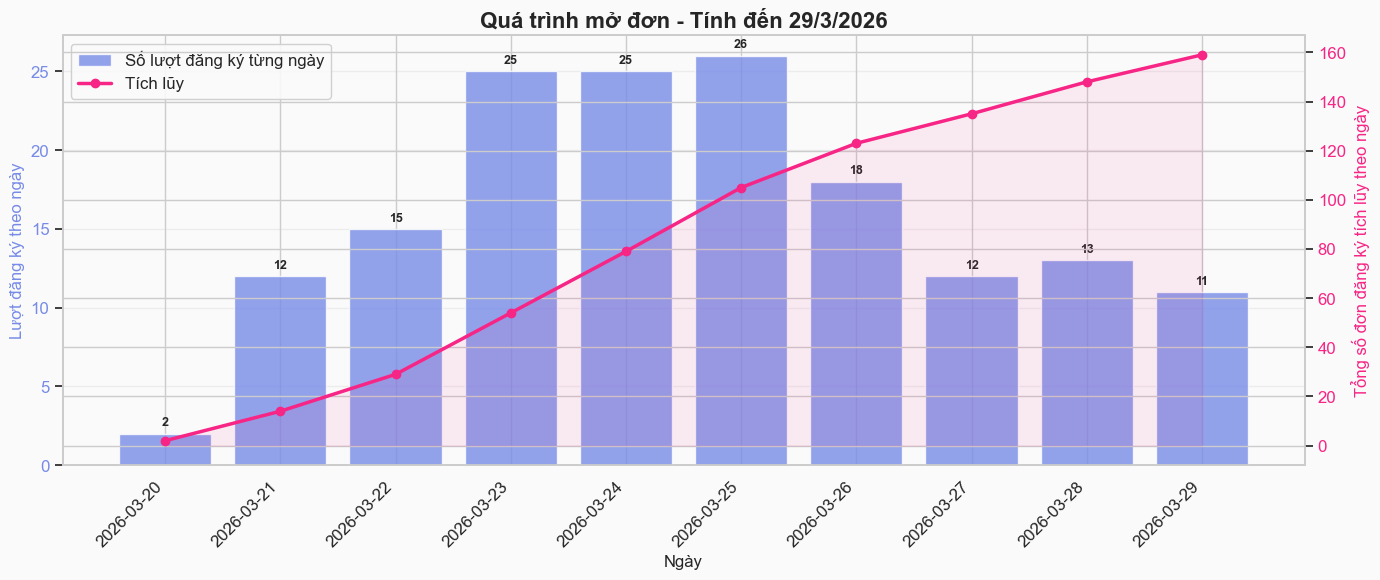

<Figure size 1200x600 with 0 Axes>

In [57]:
# ── Daily Registrations + Cumulative Line ─────────────────────
reg_by_date = df.groupby('reg_date').size().reset_index(name='count')
reg_by_date = reg_by_date.sort_values('reg_date')
reg_by_date['cumulative'] = reg_by_date['count'].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart
bars = ax1.bar(range(len(reg_by_date)), reg_by_date['count'],
               color=PALETTE[0], alpha=0.8, label='Số lượt đăng ký từng ngày', zorder=3)
ax1.set_xlabel('Ngày')
ax1.set_ylabel('Lượt đăng ký theo ngày', color=PALETTE[0])
ax1.tick_params(axis='y', labelcolor=PALETTE[0])

# Add value labels on bars
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                 f'{int(h)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Cumulative line on twin axis
ax2 = ax1.twinx()
ax2.plot(range(len(reg_by_date)), reg_by_date['cumulative'],
         color=PALETTE[3], linewidth=2.5, marker='o', markersize=6,
         label='Tích lũy', zorder=4)
ax2.set_ylabel('Tổng số đơn đăng ký tích lũy theo ngày', color=PALETTE[3])
ax2.tick_params(axis='y', labelcolor=PALETTE[3])
ax2.fill_between(range(len(reg_by_date)), reg_by_date['cumulative'],
                 alpha=0.08, color=PALETTE[3])

# X-axis labels
ax1.set_xticks(range(len(reg_by_date)))
ax1.set_xticklabels([str(d) for d in reg_by_date['reg_date']], rotation=45, ha='right')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)

ax1.set_title('Quá trình mở đơn - Tính đến 29/3/2026')
ax1.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()
plt.savefig('daily_registrations.png', dpi=300, bbox_inches='tight')

---
## 4. Institution Distribution
> ⚠️ Counted at the **individual member level** (from the `university` field), since teams can include members from multiple institutions.

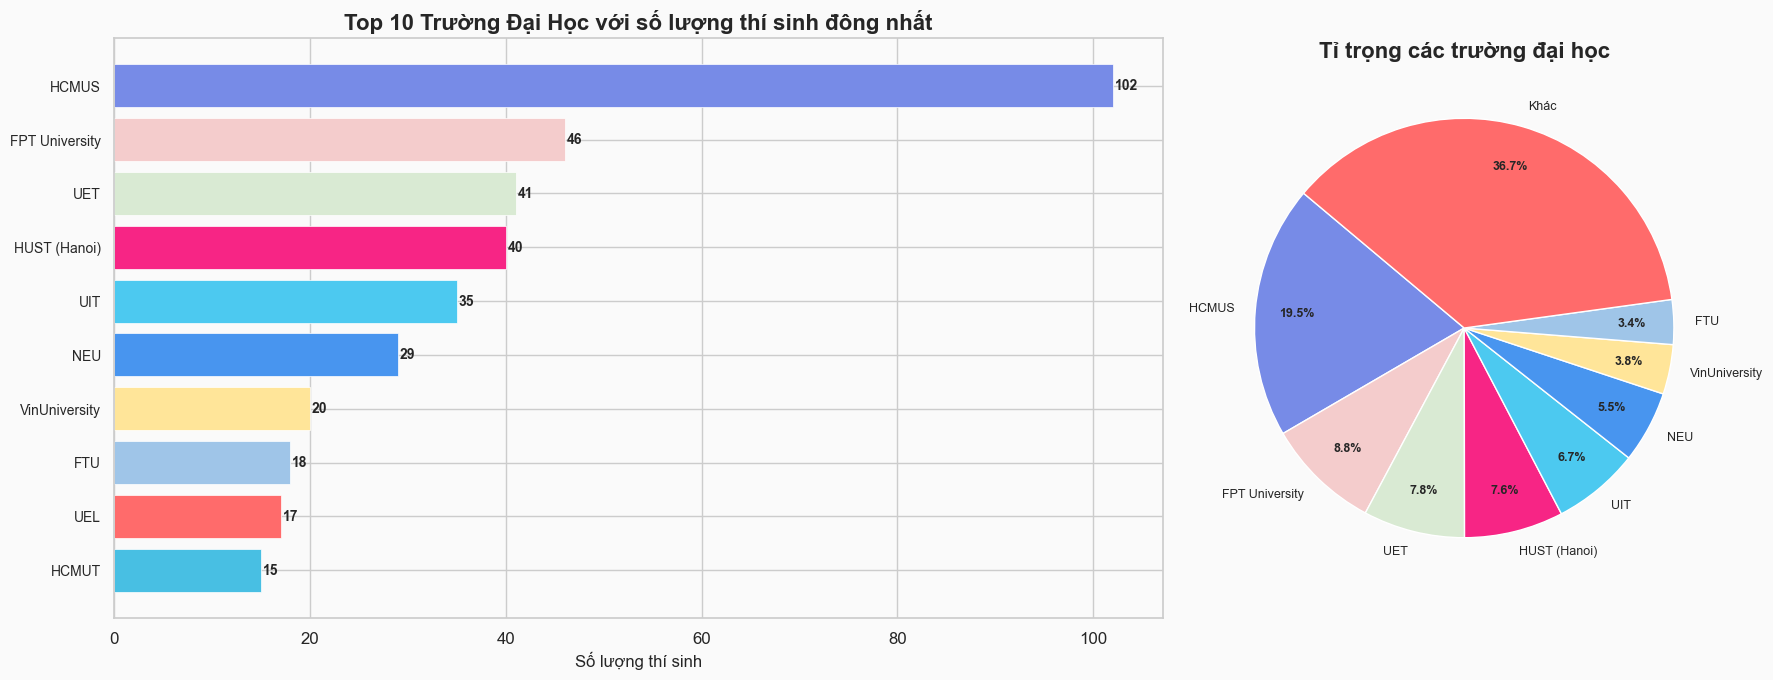

<Figure size 1200x600 with 0 Axes>

In [58]:
# ── Top Institutions Bar Chart (MEMBER-level university) ──────
# inst_counts was already computed from members_df['university'] in Section 2
top_n = min(10, len(inst_counts))
top_inst = inst_counts.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})

# Horizontal bar chart
colors = [PALETTE[i % len(PALETTE)] for i in range(top_n)]
bars = axes[0].barh(range(top_n), top_inst.values[::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(top_n))
# Truncate long names
labels = [name[:40] + '...' if len(str(name)) > 40 else str(name) for name in top_inst.index[::-1]]
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_xlabel('Số lượng thí sinh')
axes[0].set_title(f'Top {top_n} Trường Đại Học với số lượng thí sinh đông nhất')

for bar, val in zip(bars, top_inst.values[::-1]):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=10, fontweight='bold')

# Pie chart: top 5 + Other
top8 = inst_counts.head(8)
other = inst_counts.iloc[8:].sum() if len(inst_counts) > 8 else 0
pie_data = list(top8.values)
pie_labels = [str(n)[:25] for n in top8.index]
if other > 0:
    pie_data.append(other)
    pie_labels.append('Khác')

wedges, texts, autotexts = axes[1].pie(
    pie_data, labels=pie_labels, autopct='%1.1f%%',
    colors=PALETTE[:len(pie_data)], startangle=140,
    pctdistance=0.8, textprops={'fontsize': 9}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1].set_title('Tỉ trọng các trường đại học')

fig.tight_layout()
plt.show()
plt.savefig('uni_dis.png', dpi=300, bbox_inches='tight')

---
## 5. Team Size & Member Demographics

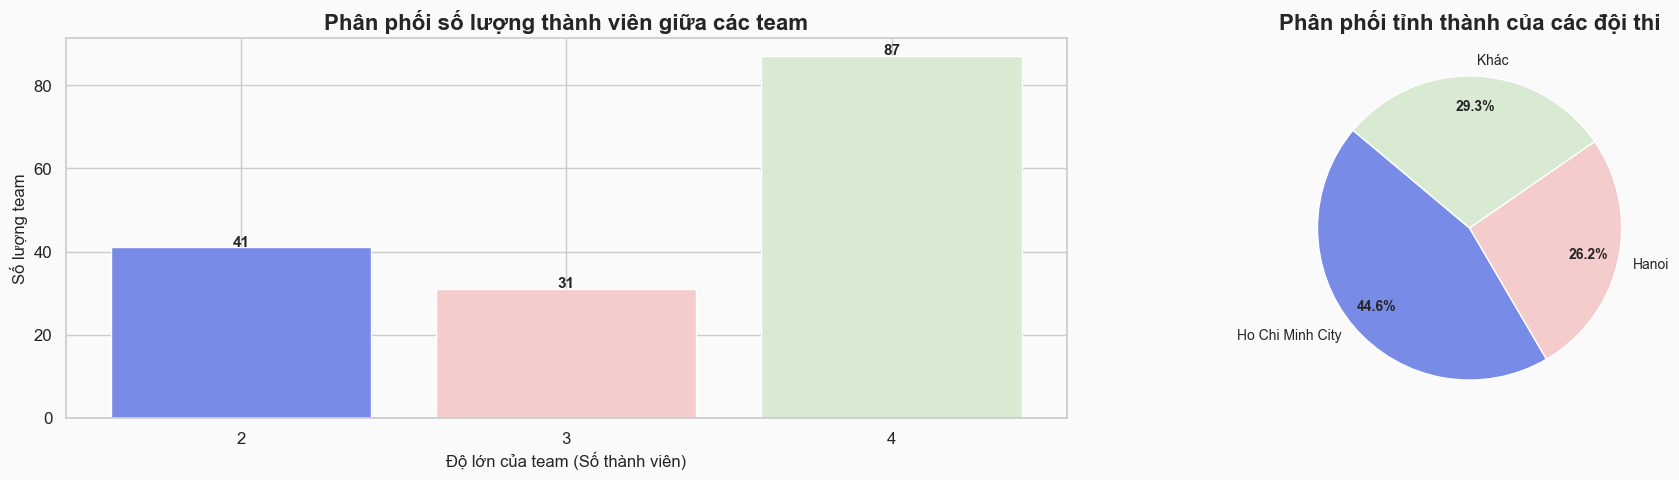

<Figure size 1200x600 with 0 Axes>

In [59]:
# ── Team Size Distribution ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Histogram
size_counts = df['team_size'].value_counts().sort_index()
axes[0].bar(size_counts.index, size_counts.values, color=PALETTE[:len(size_counts)], edgecolor='white', linewidth=1)
for i, (sz, cnt) in enumerate(zip(size_counts.index, size_counts.values)):
    axes[0].text(sz, cnt + 0.3, str(cnt), ha='center', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Độ lớn của team (Số thành viên)')
axes[0].set_ylabel('Số lượng team')
axes[0].set_title('Phân phối số lượng thành viên giữa các team')
axes[0].set_xticks(size_counts.index)

# Role distribution (if available)
# if len(members_df) > 0 and 'role' in members_df.columns:
#     role_counts = members_df['role'].value_counts()
#     wedges, texts, autotexts = axes[1].pie(
#         role_counts.values, labels=role_counts.index, autopct='%1.1f%%',
#         colors=[PALETTE[0], PALETTE[3], PALETTE[4]][:len(role_counts)],
#         startangle=90, textprops={'fontsize': 11}
#     )
#     for at in autotexts:
#         at.set_fontweight('bold')
#     axes[1].set_title('Member Roles')
# else:
#     axes[1].text(0.5, 0.5, 'Role data not available', ha='center', va='center',
#                  fontsize=14, transform=axes[1].transAxes)
#     axes[1].set_title('Member Roles')

# City distribution
if len(members_df) > 0 and 'city' in members_df.columns:
    city_counts = members_df['city'].value_counts()
    # Pull out "Multi-campus/Other" to the end for better visual sorting
    if 'Multi-campus/Other' in city_counts:
        other_val = city_counts.pop('Multi-campus/Other')
        city_counts['Khác'] = other_val
    wedges, texts, autotexts = axes[1].pie(
        city_counts.values, labels=city_counts.index, autopct='%1.1f%%',
        colors=PALETTE[:len(city_counts)],
        startangle=140, pctdistance=0.8, textprops={'fontsize': 10}
    )
    for at in autotexts:
        at.set_fontweight('bold')
    axes[1].set_title('Phân phối tỉnh thành của các đội thi')
else:
    axes[1].axis('off')

fig.tight_layout()
plt.show()
plt.savefig('city_dis.png', dpi=300, bbox_inches='tight')

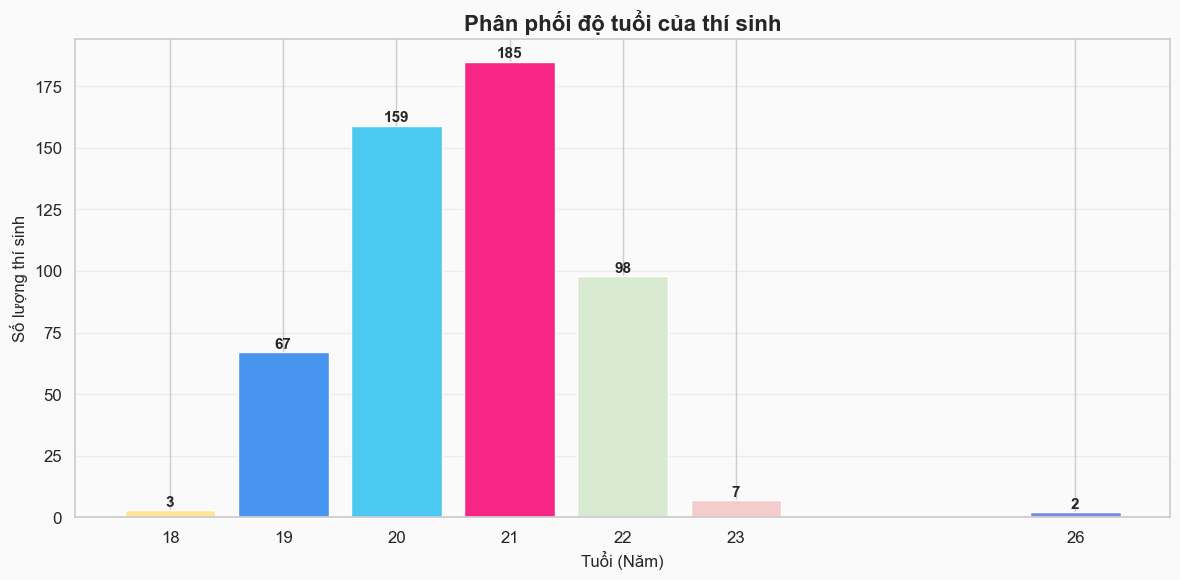

<Figure size 1200x600 with 0 Axes>

In [60]:
# ── Member Age Distribution ────────────────────────────────────
if 'dob' in members_df.columns:
    # Convert 'dob' string to a datetime object, handling bad data safely
    members_df['dob_dt'] = pd.to_datetime(members_df['dob'], errors='coerce')
    
    # Calculate age using the current project year (2026)
    current_year = 2026 
    members_df['age'] = current_year - members_df['dob_dt'].dt.year
    
    # Filter out potential typing errors in DOB (e.g., age > 40 or < 15)
    valid_ages = members_df[(members_df['age'] >= 15) & (members_df['age'] <= 40)]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create the sorted count for ages
    age_counts = valid_ages['age'].value_counts().sort_index()
    
    # Plot using a color matching your existing PALETTE (e.g. pinkish)
    bars = ax.bar(age_counts.index.astype(int), age_counts.values, 
                  color=[PALETTE[i % len(PALETTE)] for i in range(len(age_counts))][::-1], edgecolor='white', linewidth=1)
    
    ax.set_xticks(age_counts.index.astype(int))
    ax.set_xlabel('Tuổi (Năm)', fontsize=12)
    ax.set_ylabel('Số lượng thí sinh', fontsize=12)
    ax.set_title('Phân phối độ tuổi của thí sinh', fontsize=16, fontweight='bold')
    
    # Annotate the heights on top of each bar
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                    f'{int(h)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
            
    # Add a simple grid for easy reading
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    plt.show()
    plt.savefig('age_dis.png', dpi=300, bbox_inches='tight')
else:
    print("ℹ️ No 'dob' column found in member data.")


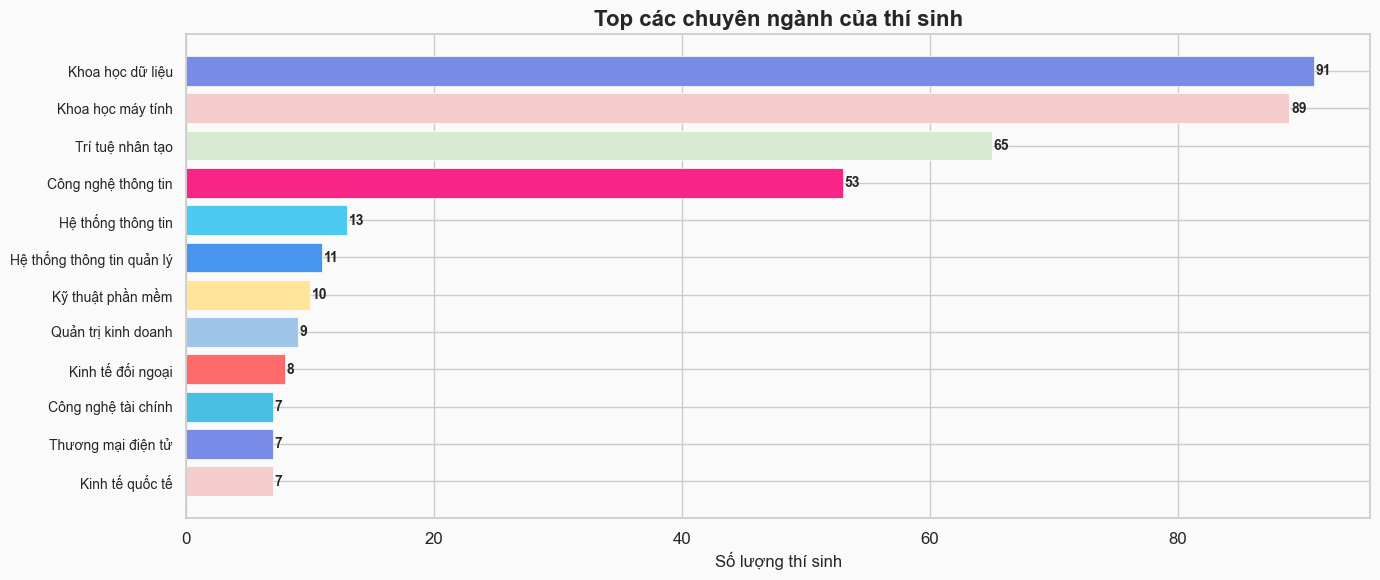

<Figure size 1200x600 with 0 Axes>

In [61]:
# ── Major / Field Distribution ────────────────────────────────
if len(members_df) > 0 and 'major' in members_df.columns:
    major_counts = members_df['major'].dropna().value_counts()
    top_majors = major_counts.head(12)

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.barh(range(len(top_majors)), top_majors.values[::-1],
                   color=[PALETTE[i % len(PALETTE)] for i in range(len(top_majors))][::-1],
                   edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top_majors)))
    labels = [str(m)[:45] + '...' if len(str(m)) > 45 else str(m) for m in top_majors.index[::-1]]
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Số lượng thí sinh')
    ax.set_title('Top các chuyên ngành của thí sinh')

    for bar, val in zip(bars, top_majors.values[::-1]):
        ax.text(val + 0.15, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()
    plt.savefig('major_dis.png', dpi=300, bbox_inches='tight')
else:
    print("ℹ️  No 'major' column found in member data.")